In [1]:
import sys
import csv
import shutil
from pathlib import Path

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [9]:
# ===== user settings =====
GSASII_DIR = "~/src/GSASII/GSASII/"     # GSASIIscriptable.py がある場所
GPX_IN = "start.gpx"                    # 既にデータ読込済みの .gpx
OUTDIR = Path("work_tof/tutorial_GSASII/cycle")
LOGFILE = OUTDIR / "refine_log.csv"

LIMITS = [12000.0, 100000.0]            # 必要に応じて変更
MAX_CYC_PER_CALL = 1                    # 1サイクルずつ回す
N_REPEAT_EACH_STEP = 5                  # 各stepを何回繰り返すか

#WORKDIR = Path("~/work_kek/software/BBO-Rietveld/work_tof/tutorial_GSASII/NAC")
WORKDIR = Path("~/work/gsas2/BBO_Rietveld/work_tof/tutorial_GSASII/NAC")
CIF_FILE = WORKDIR / "NAC.cif"
POWDER_FILE = WORKDIR / "PG3_22048.gsa"      # TOF powder data
INSTPRM_FILE = WORKDIR / "POWGEN_1066.instprm"  # TOF instrument parameter

GPX_OUT = OUTDIR / "tof_refine.gpx"
LOGFILE = OUTDIR / "refine_log.csv"

PHASE_NAME = "NAC"
DATABANK = 1
INSTBANK = 1

MAX_CYC_PER_CALL = 1
# =========================

In [10]:
# GSAS-IIのインストール先に合わせて変更
sys.path.append('~/src/GSASII/GSASII/')
import GSASIIscriptable as G2sc

In [11]:
def get_rvals(gpx):
    return gpx.data["Covariance"]["data"].get("Rvals", {})


def get_cell(gpx):
    phase = gpx.phases()[0]
    cell = phase.data["General"]["Cell"]
    return {
        "a": cell[1],
        "b": cell[2],
        "c": cell[3],
        "alpha": cell[4],
        "beta": cell[5],
        "gamma": cell[6],
        "V": cell[7],
    }


def get_inst(gpx):
    hist = gpx.histograms()[0]
    inst = hist.data["Instrument Parameters"][0]

    def value(key):
        if key not in inst:
            return None
        return inst[key][1] if len(inst[key]) > 1 else inst[key][0]

    def refine_flag(key):
        if key not in inst or len(inst[key]) < 3:
            return None
        return inst[key][2]

    return {
        "difC": value("difC"),
        "Zero": value("Zero"),
        "difC_refine": refine_flag("difC"),
        "Zero_refine": refine_flag("Zero"),
    }


def write_log(gpx, step_name, cycle):
    r = get_rvals(gpx)
    row = {
        "step": step_name,
        "cycle": cycle,
        "Rwp": r.get("Rwp"),
        "Rp": r.get("Rp"),
        "GOF": r.get("GOF"),
        "chisq": r.get("chisq"),
        **get_cell(gpx),
        **get_inst(gpx),
    }

    write_header = not LOGFILE.exists()
    with open(LOGFILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header:
            writer.writeheader()
        writer.writerow(row)

    print(
        f"{step_name:16s} cycle={cycle:02d} "
        f"Rwp={row['Rwp']} GOF={row['GOF']} "
        f"a={row['a']:.6f} difC={row['difC']} Zero={row['Zero']}"
    )


def fix_inst_params(gpx, keys=("difC", "Zero")):
    hist = gpx.histograms()[0]
    inst = hist.data["Instrument Parameters"][0]
    for key in keys:
        if key in inst and len(inst[key]) >= 3:
            inst[key][2] = False


def setup_project():
    gpx = G2sc.G2Project(newgpx=str(GPX_OUT))

    phase = gpx.add_phase(
        str(CIF_FILE),
        phasename=PHASE_NAME,
        fmthint="CIF",
    )

    hist = gpx.add_powder_histogram(
        str(POWDER_FILE),
        str(INSTPRM_FILE),
        phases=[phase],
        fmthint="GSAS powder",
        databank=DATABANK,
        instbank=INSTBANK,
    )

    hist.set_refinements({
        "Limits": LIMITS,
        "Background": {
            "type": "chebyschev-1",
            "no. coeffs": 1,
            "refine": False,
        },
    })

    gpx.data["Controls"]["data"]["max cyc"] = MAX_CYC_PER_CALL

    gpx.save()
    return gpx


def run_step(gpx, name, step, n_repeat=5):
    for i in range(1, n_repeat + 1):
        gpx.do_refinements([step])
        gpx.save(str(OUTDIR / f"{name}_cycle_{i}.gpx"))
        write_log(gpx, name, i)

In [22]:
def main():
    gpx = setup_project()

    phase = gpx.phases()[0]
    hist = gpx.histograms()[0]
    inst = hist.data["Instrument Parameters"][0]

    #---------------------------------------
    # セルパラメータ、装置パラメータ、スケールを固定
    #---------------------------------------
    phase.set_refinements({"Cell": False})
    inst["Zero"][2] = False
    inst["difC"][2] = False

    hist.data["Sample Parameters"]["Scale"][1] = False

    #---------------------
    # バックグラウンドを精密化
    #---------------------
    #hist.set_refinements({
    #    "Background": {
    #        "type": "chebyschev-1",
    #        "no. coeffs": 1,
    #        "refine": True,
    #        }
    #    })

    run_step(gpx, "background_only", {
        "set": {
            "Background": {
                "type": "chebyschev-1",
                "no. coeffs": 1,
                "refine": True,
            }
        }
    }, n_repeat=5)


    #---------------
    # スケールを精密化
    #---------------
    hist.data["Sample Parameters"]["Scale"][1] = True

    run_step(gpx, "scale_only", {
        "set": {
            "Sample Parameters": ["Scale"]
        }
    }, n_repeat=1)
    

    #---------------
    # ここで初めて Cell をON
    # ただし、装置パラメータは固定のまま
    #---------------
    phase.set_refinements({"Cell": True})
    #inst["Zero"][2] = False
    #inst["difC"][2] = False

    #steps = [
    #    ("cell", {"set": {"Cell": True}}, 5),
    #]

    #for name, step, nrep in steps:
    #    run_step(gpx, name, step, n_repeat=nrep)
    
    run_step(gpx, "scale_only", {
        "set": {
            "cell": ["Cell"]
        }
    }, n_repeat=1)



    #---------------------------------
    # 全部固定し、原子位置と温度因子を精密化
    #---------------------------------
    #phase.set_refinements({"Cell": False})
    #fix_inst_params(gpx, keys=("difC", "Zero"))


    
    # Cell, Zero, difC は固定
    phase.set_refinements({"Cell": False})
    inst["Zero"][2] = False
    inst["difC"][2] = False

    # Background, Scale も一度固定
    hist.data["Background"][0][1] = False
    hist.data["Sample Parameters"]["Scale"][1] = False



    
    run_step(gpx, "atom_xyz_only", {
        "set": {
            "Atoms": {"all": "X"}
        }
    }, n_repeat=5)


    
    # Uだけ
    run_step(gpx, "uiso_only", {
        "set": {
            "Atoms": {"all": "U"}
        }
    }, n_repeat=5)



    
    hist.data["Sample Parameters"]["Scale"][1] = True


    
    run_step(gpx, "scale_final", {
        "set": {
            "Sample Parameters": ["Scale"]
        }
    }, n_repeat=1)



    

    run_step(gpx, "background_only", {
        "set": {
            "Background": {
                "type": "chebyschev-1",
                "no. coeffs": 1,
                "refine": True,
            }
        }
    }, n_repeat=5)



    
    # 原子位置だけ
    run_step(gpx, "atom_xyz_only", {
        "set": {"Atoms": {"all": "X"}}
    }, n_repeat=5)

    # Uだけ
    run_step(gpx, "uiso_only", {
        "set": {"Atoms": {"all": "U"}}
    }, n_repeat=5)

    # Scaleだけ
    run_step(gpx, "scale_final", {
        "set": {"Sample Parameters": ["Scale"]}
    }, n_repeat=1)




    
    # TOF profile terms
    run_step(gpx, "scale_final", {
        "set": {"Instrument Parameters": ['alpha', 'beta-0', 'beta-1', 'beta-q']}
    }, n_repeat=1)


    

    # 原子位置だけ
    run_step(gpx, "atom_xyz_only", {
        "set": {"Atoms": {"all": "X"}}
    }, n_repeat=5)

    # Uだけ
    run_step(gpx, "uiso_only", {
        "set": {"Atoms": {"all": "U"}}
    }, n_repeat=5)



    
    # Scaleだけ
    run_step(gpx, "scale_final", {
        "set": {"Sample Parameters": ["Scale"]}
    }, n_repeat=1)

    gpx.save(str(OUTDIR / "final.gpx"))

    print(f"\nFinal GPX: {OUTDIR / 'final.gpx'}")
    print(f"Log CSV  : {LOGFILE}")

In [23]:
main()

Keyed packet: ['Ca1', '0.0083', '0.0096', '0.0080', '0.0000', '0.0000', '-0.0000']
Keyed packet: ['Al1', '0.0078', '0.0078', '0.0078', '-0.0007', '-0.0007', '-0.0007']
Keyed packet: ['Na1', '0.0255', '0.0255', '0.0255', '-0.0074', '-0.0074', '-0.0074']
Keyed packet: ['F1', '0.0102', '0.0110', '0.0128', '0.0006', '-0.0018', '0.0020']
Keyed packet: ['F2', '0.0115', '0.0158', '0.0124', '-0.0071', '0.0007', '0.0024']
Keyed packet: ['F3', '0.0095', '0.0095', '0.0095', '0.0007', '0.0007', '0.0007']
/Users/tsunetomo/work/gsas2/BBO_Rietveld/work_tof/tutorial_GSASII/NAC/NAC.cif read by Reader CIF
gpx file saved as /Users/tsunetomo/work/gsas2/BBO_Rietveld/work_tof/tutorial_GSASII/cycle/tof_refine.gpx
/Users/tsunetomo/work/gsas2/BBO_Rietveld/work_tof/tutorial_GSASII/NAC/PG3_22048.gsa block # 1 read by Reader GSAS powder data
Instrument parameters read: /Users/tsunetomo/work/gsas2/BBO_Rietveld/work_tof/tutorial_GSASII/NAC/POWGEN_1066.instprm (G2 fmt) bank 1
gpx file saved as /Users/tsunetomo/work/

ValueError: ('Unknown refinement key', 'cell')

## 差分プロファイル

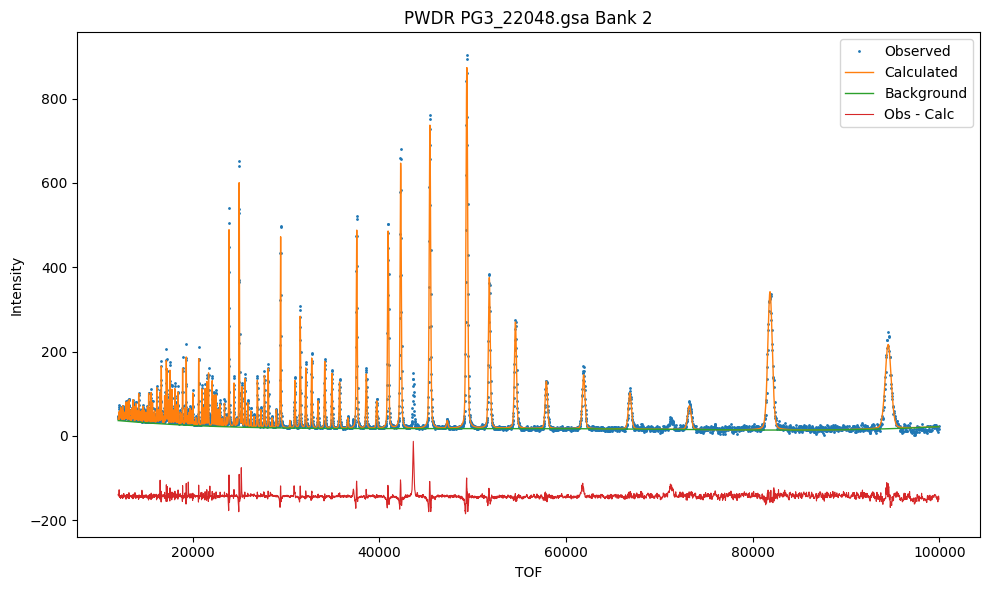

Histogram: PWDR PG3_22048.gsa Bank 2
Limits: [(np.float64(6778.4369582105), np.float64(103793.9994994135)), [12000.0, 100000.0]]
CSV saved: /Users/tsunetomo/work/gsas2/BBO_Rietveld/work_tof/tutorial_GSASII/cycle/profile_difference.csv
PNG saved: /Users/tsunetomo/work/gsas2/BBO_Rietveld/work_tof/tutorial_GSASII/cycle/profile_difference.png


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== user settings =====
GSASII_DIR = "/path/to/GSAS-II/GSASII"
#GPX_FILE = "/Users/tsunetomo/work_kek/software/BBO-Rietveld/work_tof/tutorial_GSASII/cycle/final.gpx"
#OUTDIR = Path("/Users/tsunetomo/work_kek/software/BBO-Rietveld/work_tof/tutorial_GSASII/cycle")
GPX_FILE = "/Users/tsunetomo/work/gsas2/BBO_Rietveld/work_tof/tutorial_GSASII/cycle/final.gpx"
OUTDIR = Path("/Users/tsunetomo/work/gsas2/BBO_Rietveld/work_tof/tutorial_GSASII/cycle")
HIST_INDEX = 0
# =========================

gpx = G2sc.G2Project(GPX_FILE)
hist = gpx.histograms()[HIST_INDEX]

x = np.asarray(hist.data["data"][1][0])
yobs = np.asarray(hist.data["data"][1][1])
w = np.asarray(hist.data["data"][1][2])
ycalc = np.asarray(hist.data["data"][1][3])
ybkg = np.asarray(hist.data["data"][1][4])

diff = yobs - ycalc

lo, hi = hist.data["Limits"][1]
mask = (x >= lo) & (x <= hi)

df = pd.DataFrame({
    "x": x[mask],
    "yobs": yobs[mask],
    "ycalc": ycalc[mask],
    "ybkg": ybkg[mask],
    "diff": diff[mask],
    "weight": w[mask],
})

csv_path = OUTDIR / "profile_difference.csv"
png_path = OUTDIR / "profile_difference.png"

df.to_csv(csv_path, index=False)

offset = 1.1 * np.nanmax(np.abs(df["diff"]))

plt.figure(figsize=(10, 6))
plt.plot(df["x"], df["yobs"], ".", markersize=2, label="Observed")
plt.plot(df["x"], df["ycalc"], "-", linewidth=1.0, label="Calculated")
plt.plot(df["x"], df["ybkg"], "-", linewidth=1.0, label="Background")
plt.plot(df["x"], df["diff"] - offset, "-", linewidth=0.8, label="Obs - Calc")

plt.xlabel("TOF")
plt.ylabel("Intensity")
plt.title(hist.name)
plt.legend()
plt.tight_layout()
plt.savefig(png_path, dpi=200)
#plt.close()
plt.show()

print("Histogram:", hist.name)
print("Limits:", hist.data["Limits"])
print("CSV saved:", csv_path)
print("PNG saved:", png_path)